In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("D:/EVELATE_LAS_INTERSHIP/Healthcare_NoShow_Prediction/data/eda_cleaned_appointments.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (110522, 18)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays,Weekday,Month,AgeGroup
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday,4,Senior
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday,4,Adult
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday,4,Senior
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday,4,Child
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday,4,Adult


In [3]:
print(df.info())

print("\nColumns:\n")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 110522 entries, 0 to 110521
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110522 non-null  float64
 1   AppointmentID   110522 non-null  int64  
 2   Gender          110522 non-null  str    
 3   ScheduledDay    110522 non-null  str    
 4   AppointmentDay  110522 non-null  str    
 5   Age             110522 non-null  int64  
 6   Neighbourhood   110522 non-null  str    
 7   Scholarship     110522 non-null  int64  
 8   Hipertension    110522 non-null  int64  
 9   Diabetes        110522 non-null  int64  
 10  Alcoholism      110522 non-null  int64  
 11  Handcap         110522 non-null  int64  
 12  SMS_received    110522 non-null  int64  
 13  No-show         110522 non-null  int64  
 14  WaitingDays     110522 non-null  int64  
 15  Weekday         110522 non-null  str    
 16  Month           110522 non-null  int64  
 17  AgeGroup        11052

In [4]:
if df["No-show"].dtype == "object":
    df["No-show"] = df["No-show"].map({
        "No": 0,
        "Yes": 1
    })

print(df["No-show"].value_counts())

No-show
0    88208
1    22314
Name: count, dtype: int64


In [5]:
df = df.drop(columns=[
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay"
])

print(df.columns.tolist())

['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitingDays', 'Weekday', 'Month', 'AgeGroup']


In [6]:
label_encoders = {}

categorical_columns = [
    "Gender",
    "Neighbourhood",
    "Weekday",
    "AgeGroup"
]

for col in categorical_columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col].astype(str))

    label_encoders[col] = encoder

print("Categorical Encoding Completed")

df.head()

Categorical Encoding Completed


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays,Weekday,Month,AgeGroup
0,0,62,39,0,1,0,0,0,0,0,0,0,4,2
1,1,56,39,0,0,0,0,0,0,0,0,0,4,0
2,0,62,45,0,0,0,0,0,0,0,0,0,4,2
3,0,8,54,0,0,0,0,0,0,0,0,0,4,1
4,0,56,39,0,1,1,0,0,0,0,0,0,4,0


In [7]:
X = df.drop("No-show", axis=1)

y = df["No-show"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (110522, 13)
Target Shape : (110522,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (88417, 13)
Testing Data : (22105, 13)


In [9]:
model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [10]:
# Predict on test data
y_pred = model.predict(X_test)

print("Predictions Completed!")

print(y_pred[:10])

Predictions Completed!
[0 0 0 0 0 0 0 0 0 0]


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7979


In [12]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.3913


In [13]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.0020


In [14]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.0040


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[17628    14]
 [ 4454     9]]


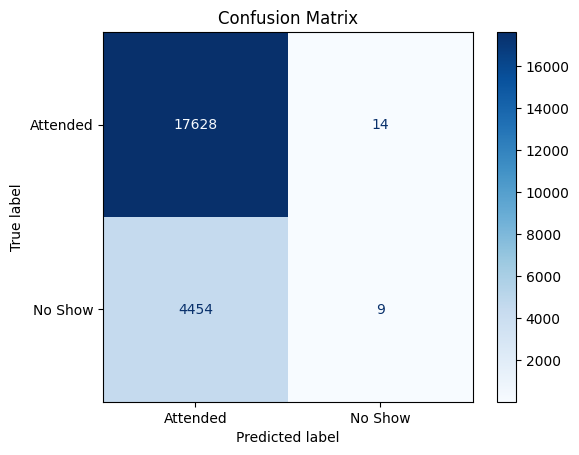

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Attended", "No Show"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.39      0.00      0.00      4463

    accuracy                           0.80     22105
   macro avg       0.59      0.50      0.45     22105
weighted avg       0.72      0.80      0.71     22105



In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,WaitingDays,0.798185
1,Age,0.142044
8,SMS_received,0.024830
2,Neighbourhood,0.009271
0,Gender,0.006222
10,Weekday,0.005496
12,AgeGroup,0.003879
3,Scholarship,0.003755
6,Alcoholism,0.002662
5,Diabetes,0.001929


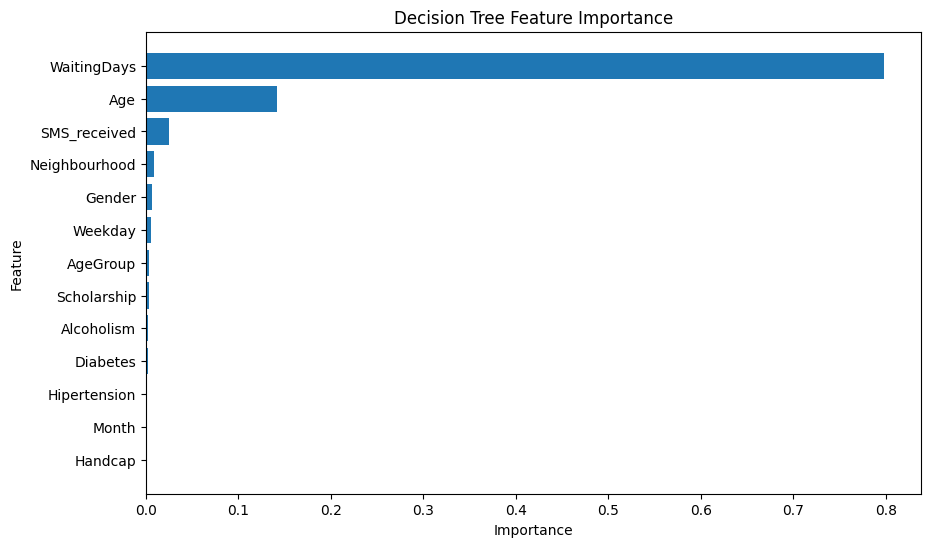

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [20]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "decision_tree.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
